# Perfect Rainfall Prediction Model
## Comprehensive Data Cleaning and ML Pipeline

This notebook implements best practices for:
- Data cleaning and preprocessing
- Exploratory data analysis
- Feature engineering
- Model training with multiple algorithms
- Hyperparameter tuning
- Model evaluation

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading and Initial Exploration

In [2]:
# Load data
df = pd.read_csv(r"C:\Users\Admin\Desktop\-rainfall-pradction-ml\eth_householdgeovariables_y5.csv")

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (4890, 52)

First few rows:


,household_id,dist_road,dist_market,dist_border,dist_popcenter,dist_admhq,af_bio_1_x,af_bio_8_x,af_bio_12_x,af_bio_13_x,...,c2_evimax_avg,c2_grn_avg,c2_sen_avg,c2_h2021_eviarea,c2_h2021_evimax,c2_h2021_grn,c2_h2021_sen,lat_dd_mod,lon_dd_mod,suppress
0,20101010100104011,7.7,162.300003,82.900002,0.4,0.0,283,307,184,47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.749938,41.080363,0
1,20101010100104022,7.7,162.300003,82.900002,0.4,0.0,283,307,184,47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.749938,41.080363,0
2,20101010100104033,7.7,162.300003,82.900002,0.4,0.0,283,307,184,47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.749938,41.080363,0
3,20101010100104044,7.7,162.300003,82.900002,0.4,0.0,283,307,184,47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.749938,41.080363,0
4,20101010100104055,7.7,162.300003,82.900002,0.4,0.0,283,307,184,47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.749938,41.080363,0


In [3]:
# Basic information
print("Data Types:")
print(df.dtypes.value_counts())
print("\nDataset Info:")
df.info()

Data Types:
int64      29
float64    21
object      2
Name: count, dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4890 entries, 0 to 4889
Data columns (total 52 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   household_id       4890 non-null   int64  
 1   dist_road          4890 non-null   float64
 2   dist_market        4890 non-null   float64
 3   dist_border        4890 non-null   float64
 4   dist_popcenter     4890 non-null   float64
 5   dist_admhq         4890 non-null   float64
 6   af_bio_1_x         4890 non-null   int64  
 7   af_bio_8_x         4890 non-null   int64  
 8   af_bio_12_x        4890 non-null   int64  
 9   af_bio_13_x        4890 non-null   int64  
 10  af_bio_16_x        4890 non-null   int64  
 11  afmnslp_pct        4890 non-null   int64  
 12  srtm_1k            4890 non-null   int64  
 13  popdensity         4890 non-null   int64  
 14  cropshare          4890 n

Target Variable (af_bio_12_x) Statistics:
count    4890.000000
mean      979.789980
std       387.622945
min       145.000000
25%       706.000000
50%      1033.000000
75%      1182.750000
max      1997.000000
Name: af_bio_12_x, dtype: float64


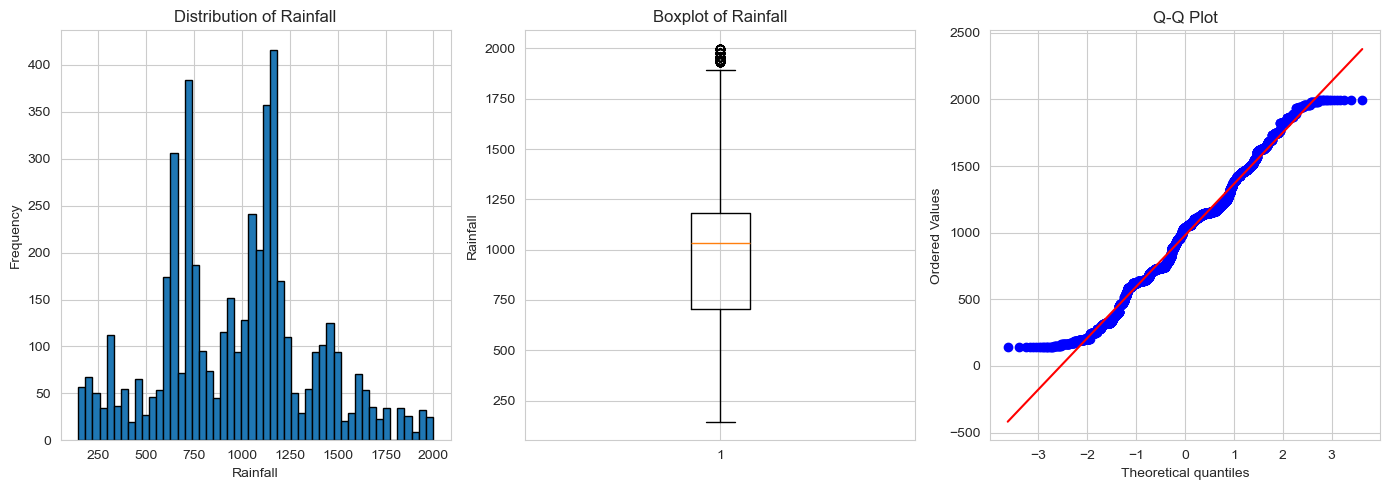

In [4]:
# Check target variable (rainfall - af_bio_12_x)
print("Target Variable (af_bio_12_x) Statistics:")
print(df['af_bio_12_x'].describe())

plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
plt.hist(df['af_bio_12_x'], bins=50, edgecolor='black')
plt.xlabel('Rainfall')
plt.ylabel('Frequency')
plt.title('Distribution of Rainfall')

plt.subplot(1, 3, 2)
plt.boxplot(df['af_bio_12_x'])
plt.ylabel('Rainfall')
plt.title('Boxplot of Rainfall')

plt.subplot(1, 3, 3)
stats.probplot(df['af_bio_12_x'], dist="norm", plot=plt)
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()

## 2. Data Cleaning - Missing Values Analysis

Columns with Missing Values:
                            Column  Missing_Count  Missing_Percentage
c2_eviarea_avg      c2_eviarea_avg           4392           89.815951
c2_evimax_avg        c2_evimax_avg           4392           89.815951
c2_grn_avg              c2_grn_avg           4392           89.815951
c2_sen_avg              c2_sen_avg           4392           89.815951
c2_h2021_eviarea  c2_h2021_eviarea           4392           89.815951
c2_h2021_evimax    c2_h2021_evimax           4392           89.815951
c2_h2021_grn          c2_h2021_grn           4392           89.815951
c2_h2021_sen          c2_h2021_sen           4392           89.815951
lat_dd_mod              lat_dd_mod             43            0.879346
lon_dd_mod              lon_dd_mod             43            0.879346


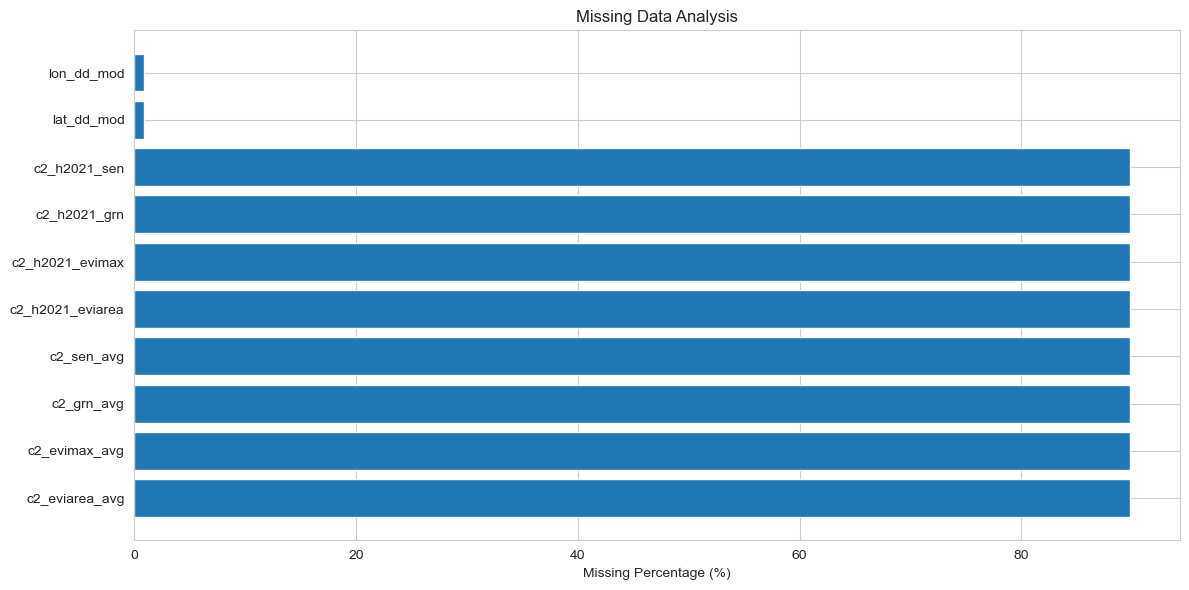

In [5]:
# Detailed missing value analysis
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
print("Columns with Missing Values:")
print(missing_data)

# Visualize missing data
if len(missing_data) > 0:
    plt.figure(figsize=(12, 6))
    plt.barh(missing_data['Column'], missing_data['Missing_Percentage'])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Data Analysis')
    plt.tight_layout()
    plt.show()

In [6]:
# Strategy for handling missing values
# Drop columns with >80% missing data
# These are the c2_* columns with 4392 missing values out of 4890 (89.8%)

high_missing_cols = missing_data[missing_data['Missing_Percentage'] > 80]['Column'].tolist()
print(f"Dropping {len(high_missing_cols)} columns with >80% missing data:")
print(high_missing_cols)

df_cleaned = df.drop(columns=high_missing_cols)

Dropping 8 columns with >80% missing data:
['c2_eviarea_avg', 'c2_evimax_avg', 'c2_grn_avg', 'c2_sen_avg', 'c2_h2021_eviarea', 'c2_h2021_evimax', 'c2_h2021_grn', 'c2_h2021_sen']


In [7]:
# Handle remaining missing values (lat_dd_mod, lon_dd_mod have 43 missing)
# For geographic coordinates, we can't impute with mean - drop these rows instead
print(f"\nRows before dropping missing coordinates: {len(df_cleaned)}")
df_cleaned = df_cleaned.dropna(subset=['lat_dd_mod', 'lon_dd_mod'])
print(f"Rows after dropping missing coordinates: {len(df_cleaned)}")

# Verify no more missing values
print(f"\nRemaining missing values: {df_cleaned.isnull().sum().sum()}")


Rows before dropping missing coordinates: 4890
Rows after dropping missing coordinates: 4847

Remaining missing values: 0


## 3. Data Cleaning - Duplicate Removal

In [8]:
# Check for duplicates
print(f"Number of duplicate rows: {df_cleaned.duplicated().sum()}")
print(f"Percentage of duplicates: {(df_cleaned.duplicated().sum() / len(df_cleaned)) * 100:.2f}%")

# Remove duplicates
df_cleaned = df_cleaned.drop_duplicates()
print(f"\nDataset shape after removing duplicates: {df_cleaned.shape}")

Number of duplicate rows: 0
Percentage of duplicates: 0.00%

Dataset shape after removing duplicates: (4847, 44)


## 4. Feature Selection and Preparation

In [9]:
# Remove non-informative columns
cols_to_drop = ['household_id', 'suppress']  # IDs and control flags
df_cleaned = df_cleaned.drop(columns=[col for col in cols_to_drop if col in df_cleaned.columns])

# Separate target variable
target = 'af_bio_12_x'  # This is rainfall
y = df_cleaned[target]
X = df_cleaned.drop(columns=[target])

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())

Features shape: (4847, 41)
Target shape: (4847,)

Feature columns (41):
['dist_road', 'dist_market', 'dist_border', 'dist_popcenter', 'dist_admhq', 'af_bio_1_x', 'af_bio_8_x', 'af_bio_13_x', 'af_bio_16_x', 'afmnslp_pct', 'srtm_1k', 'popdensity', 'cropshare', 'sq1', 'sq2', 'sq3', 'sq4', 'sq5', 'sq6', 'sq7', 'ssa_aez09', 'landcov', 'twi_ne', 'pct_urban_cluster', 'pct_urban_center', 'h2021_tot', 'h2021_wetQstart', 'h2021_wetQ', 'anntot_avg', 'wetQ_avgstart', 'wetQ_avg', 'eviarea_avg', 'evimax_avg', 'grn_avg', 'sen_avg', 'h2021_eviarea', 'h2021_evimax', 'h2021_grn', 'h2021_sen', 'lat_dd_mod', 'lon_dd_mod']


In [10]:
# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"\nNumerical features ({len(numerical_features)}): {len(numerical_features)}")

Categorical features (2): ['ssa_aez09', 'landcov']

Numerical features (39): 39


In [11]:
# One-hot encode categorical variables
if len(categorical_features) > 0:
    X = pd.get_dummies(X, columns=categorical_features, drop_first=True)
    print(f"\nAfter encoding, features shape: {X.shape}")


After encoding, features shape: (4847, 53)


## 5. Outlier Detection and Treatment

In [12]:
# Detect outliers using IQR method for numerical features
def detect_outliers_iqr(data, columns, multiplier=1.5):
    outlier_indices = set()
    
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        # Find outlier indices
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index
        outlier_indices.update(outliers)
    
    return list(outlier_indices)

# Get numerical columns from current X (after encoding)
current_numerical = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Detect outliers
outlier_indices = detect_outliers_iqr(X, current_numerical)
print(f"Number of rows with outliers: {len(outlier_indices)} ({len(outlier_indices)/len(X)*100:.2f}%)")

# Instead of removing outliers, we'll use RobustScaler which is less sensitive to outliers
print("\nWe'll use RobustScaler to handle outliers during preprocessing.")

Number of rows with outliers: 2618 (54.01%)

We'll use RobustScaler to handle outliers during preprocessing.


## 6. Correlation Analysis and Feature Selection

Top 15 features correlated with rainfall:
af_bio_16_x                       0.882814
anntot_avg                        0.863926
wetQ_avg                          0.811142
af_bio_13_x                       0.808346
h2021_tot                         0.753023
evimax_avg                        0.725165
eviarea_avg                       0.697539
h2021_eviarea                     0.694754
h2021_evimax                      0.689388
h2021_wetQ                        0.570639
sen_avg                           0.548786
srtm_1k                           0.507804
ssa_aez09_Tropic-cool/humid       0.454187
ssa_aez09_Tropic-cool/subhumid    0.435552
h2021_sen                         0.406462
Name: rainfall, dtype: float64

Bottom 15 features correlated with rainfall:
landcov_Herbaceous vegetation    -0.149545
sq4                              -0.151398
sq6                              -0.242418
dist_popcenter                   -0.245087
dist_market                      -0.256971
ssa_aez09_Tropic-cool

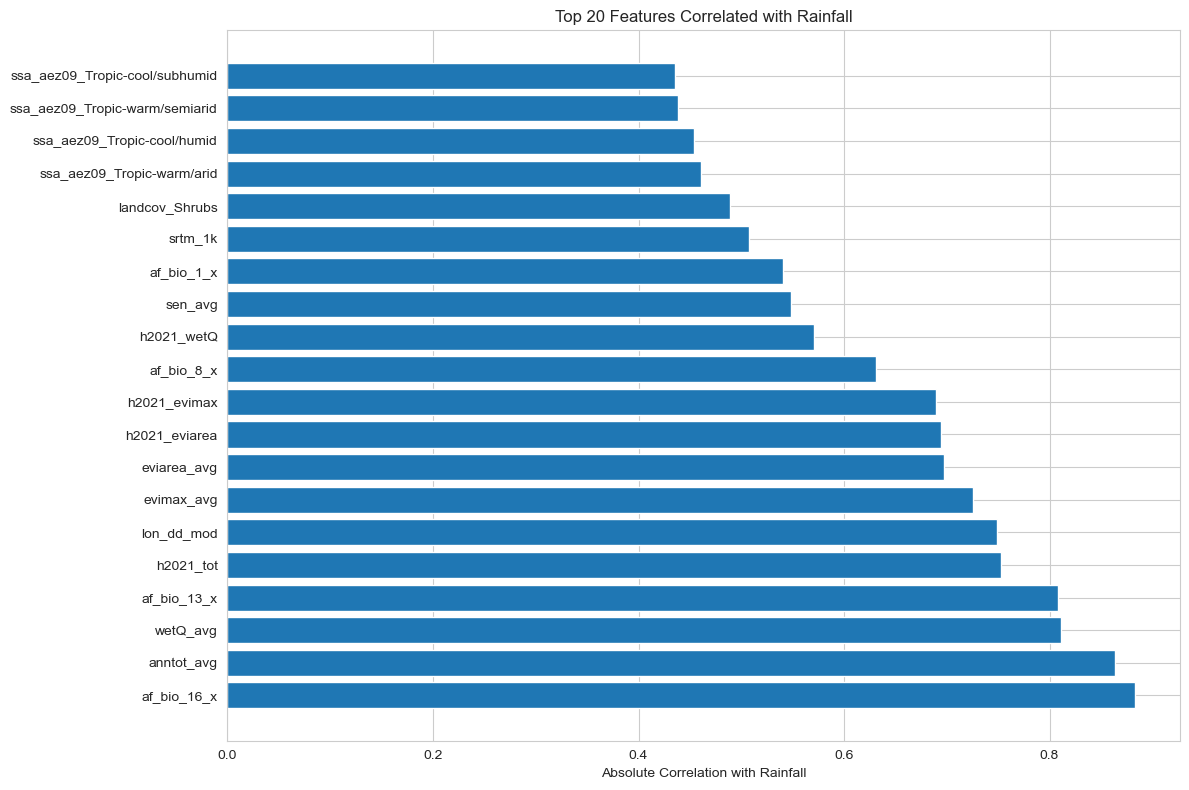

In [13]:
# Create a temporary dataframe with target for correlation analysis
X_with_target = X.copy()
X_with_target['rainfall'] = y

# Calculate correlation with target
correlation_with_target = X_with_target.corr()['rainfall'].drop('rainfall').sort_values(ascending=False)

print("Top 15 features correlated with rainfall:")
print(correlation_with_target.head(15))
print("\nBottom 15 features correlated with rainfall:")
print(correlation_with_target.tail(15))

# Visualize top correlations
plt.figure(figsize=(12, 8))
top_corr = 20
top_features = correlation_with_target.abs().sort_values(ascending=False).head(top_corr)
plt.barh(range(len(top_features)), top_features.values)
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Absolute Correlation with Rainfall')
plt.title(f'Top {top_corr} Features Correlated with Rainfall')
plt.tight_layout()
plt.show()

In [14]:
# Remove features with very low correlation (absolute correlation < 0.05)
threshold = 0.05
low_corr_features = correlation_with_target[correlation_with_target.abs() < threshold].index.tolist()
print(f"\nRemoving {len(low_corr_features)} features with correlation < {threshold}:")

X = X.drop(columns=low_corr_features)
print(f"\nFeatures remaining after correlation filtering: {X.shape[1]}")


Removing 3 features with correlation < 0.05:

Features remaining after correlation filtering: 50


## 7. Train-Test Split

In [15]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTraining target distribution:")
print(y_train.describe())
print(f"\nTest target distribution:")
print(y_test.describe())

Training set: (3877, 50)
Test set: (970, 50)

Training target distribution:
count    3877.000000
mean      991.222595
std       386.563408
min       145.000000
25%       717.000000
50%      1049.000000
75%      1186.000000
max      1997.000000
Name: af_bio_12_x, dtype: float64

Test target distribution:
count     970.000000
mean      955.234021
std       377.377677
min       145.000000
25%       696.000000
50%       973.500000
75%      1159.000000
max      1997.000000
Name: af_bio_12_x, dtype: float64


## 8. Feature Scaling

In [16]:
# Use RobustScaler (better for data with outliers)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier interpretation
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Feature scaling completed using RobustScaler.")
print(f"\nScaled training data sample:")
X_train_scaled.head()

Feature scaling completed using RobustScaler.

Scaled training data sample:


,dist_road,dist_market,dist_border,dist_popcenter,dist_admhq,af_bio_1_x,af_bio_8_x,af_bio_13_x,af_bio_16_x,afmnslp_pct,...,ssa_aez09_Tropic-warm/arid,ssa_aez09_Tropic-warm/semiarid,ssa_aez09_Tropic-warm/subhumid,landcov_Closed forest deciduous broad leaf,landcov_Closed forest evergreen broad leaf,landcov_Cropland,landcov_Herbaceous vegetation,landcov_Open forest deciduous broad leaf,landcov_Open forest unknown,landcov_Shrubs
455,0.000000,0.704030,0.395906,-0.291022,1.0,-0.681159,-0.411765,0.852713,0.334278,0.888889,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4125,-0.067568,-0.259446,0.847561,-0.040248,-0.5,-0.623188,-0.494118,0.434109,0.388102,0.555556,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
312,2.689189,0.319899,0.037892,0.501548,0.0,-0.405797,-0.388235,1.503876,1.269122,0.111111,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2624,1.270270,0.363980,0.067944,0.690403,1.0,-0.260870,-0.235294,0.333333,0.563739,1.111111,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4165,-0.108108,-0.322418,0.879791,-0.195046,-0.5,-0.362319,-0.294118,0.356589,0.362606,-0.222222,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 9. Model Training and Comparison

In [17]:
# Train multiple models
models = {
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Ridge Regression': Ridge(random_state=42),
    'Lasso Regression': Lasso(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    
    results[name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Test RMSE: {test_rmse:.4f}")
    print(f"  Test MAE: {test_mae:.4f}")
    print(f"  CV R² Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Training Random Forest...
  Train R²: 1.0000
  Test R²: 0.9998
  Test RMSE: 5.0404
  Test MAE: 0.4552
  CV R² Score: 0.9997 (+/- 0.0004)

Training Gradient Boosting...
  Train R²: 0.9971
  Test R²: 0.9960
  Test RMSE: 23.7316
  Test MAE: 15.7724
  CV R² Score: 0.9964 (+/- 0.0003)

Training Ridge Regression...
  Train R²: 0.9758
  Test R²: 0.9722
  Test RMSE: 62.9233
  Test MAE: 42.4002
  CV R² Score: 0.9748 (+/- 0.0027)

Training Lasso Regression...
  Train R²: 0.9695
  Test R²: 0.9663
  Test RMSE: 69.1953
  Test MAE: 47.2392
  CV R² Score: 0.9688 (+/- 0.0027)



MODEL COMPARISON
            Model  Train R²  Test R²  Test RMSE  Test MAE  CV R² Mean  CV R² Std
    Random Forest  0.999959 0.999821   5.040439  0.455165    0.999652   0.000404
Gradient Boosting  0.997105 0.996041  23.731636 15.772386    0.996407   0.000280
 Ridge Regression  0.975820 0.972170  62.923303 42.400166    0.974791   0.002718
 Lasso Regression  0.969452 0.966345  69.195340 47.239152    0.968805   0.002657


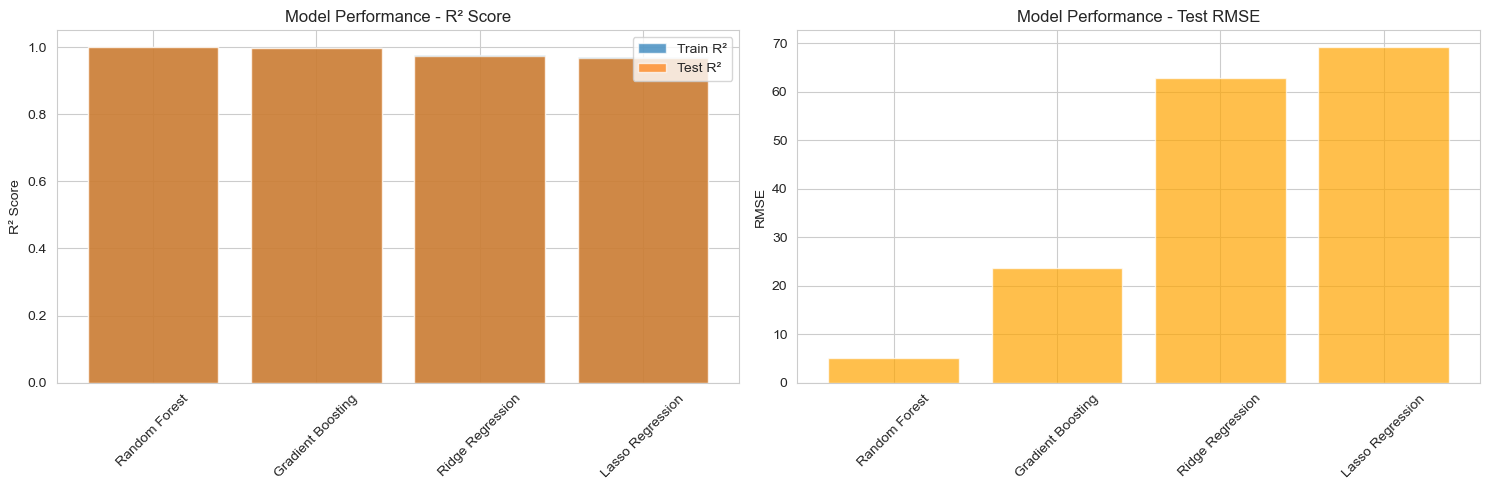

In [18]:
# Compare models
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train R²': [results[name]['train_r2'] for name in results.keys()],
    'Test R²': [results[name]['test_r2'] for name in results.keys()],
    'Test RMSE': [results[name]['test_rmse'] for name in results.keys()],
    'Test MAE': [results[name]['test_mae'] for name in results.keys()],
    'CV R² Mean': [results[name]['cv_mean'] for name in results.keys()],
    'CV R² Std': [results[name]['cv_std'] for name in results.keys()]
})

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R² comparison
axes[0].bar(comparison_df['Model'], comparison_df['Train R²'], alpha=0.7, label='Train R²')
axes[0].bar(comparison_df['Model'], comparison_df['Test R²'], alpha=0.7, label='Test R²')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Model Performance - R² Score')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# RMSE comparison
axes[1].bar(comparison_df['Model'], comparison_df['Test RMSE'], alpha=0.7, color='orange')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Model Performance - Test RMSE')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning for Best Model

In [19]:
# Select best model based on test R²
best_model_name = comparison_df.loc[comparison_df['Test R²'].idxmax(), 'Model']
print(f"Best performing model: {best_model_name}")
print(f"\nPerforming hyperparameter tuning on {best_model_name}...")

# Define parameter grid based on best model
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_model = RandomForestRegressor(random_state=42, n_jobs=-1)

elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10]
    }
    base_model = GradientBoostingRegressor(random_state=42)

elif best_model_name == 'Ridge Regression':
    param_grid = {
        'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    }
    base_model = Ridge(random_state=42)

else:  # Lasso
    param_grid = {
        'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    }
    base_model = Lasso(random_state=42)

# Perform grid search
grid_search = GridSearchCV(
    base_model,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation R² score: {grid_search.best_score_:.4f}")

Best performing model: Random Forest

Performing hyperparameter tuning on Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation R² score: 0.9997


## 11. Final Model Evaluation


FINAL MODEL PERFORMANCE

Model: Random Forest
Parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Training Set:
  R² Score: 1.0000
  RMSE: 2.4845
  MAE: 0.1983

Test Set:
  R² Score: 0.9998
  RMSE: 5.0404
  MAE: 0.4552


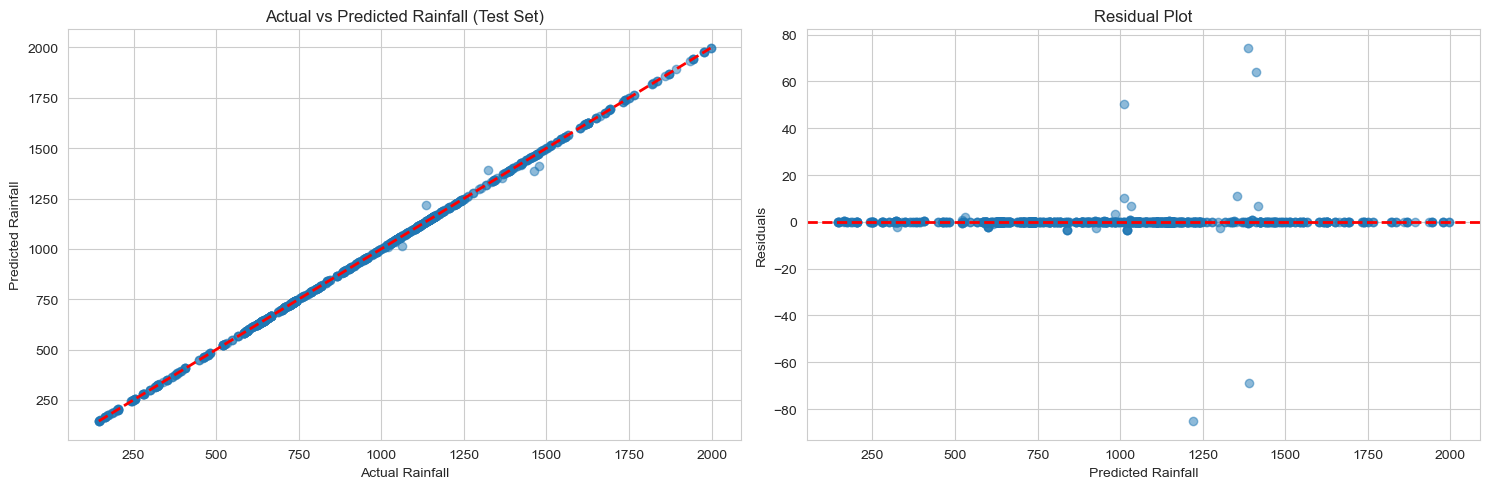

In [20]:
# Use best model from grid search
best_model = grid_search.best_estimator_

# Make predictions
y_pred_train = best_model.predict(X_train_scaled)
y_pred_test = best_model.predict(X_test_scaled)

# Calculate final metrics
print("\n" + "="*80)
print("FINAL MODEL PERFORMANCE")
print("="*80)

print(f"\nModel: {best_model_name}")
print(f"Parameters: {grid_search.best_params_}")

print("\nTraining Set:")
print(f"  R² Score: {r2_score(y_train, y_pred_train):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"  MAE: {mean_absolute_error(y_train, y_pred_train):.4f}")

print("\nTest Set:")
print(f"  R² Score: {r2_score(y_test, y_pred_test):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_test):.4f}")

# Visualize predictions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Rainfall')
axes[0].set_ylabel('Predicted Rainfall')
axes[0].set_title('Actual vs Predicted Rainfall (Test Set)')

# Residual plot
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Rainfall')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

## 12. Feature Importance Analysis


Top 20 Most Important Features:
        feature  importance
    af_bio_16_x    0.772692
     anntot_avg    0.066826
    dist_border    0.035395
      h2021_grn    0.034684
     lon_dd_mod    0.017048
        srtm_1k    0.014550
     af_bio_8_x    0.007842
     dist_admhq    0.007572
    eviarea_avg    0.005934
h2021_wetQstart    0.005744
     af_bio_1_x    0.003646
      cropshare    0.003092
        grn_avg    0.003037
    af_bio_13_x    0.002251
  h2021_eviarea    0.001640
 dist_popcenter    0.001613
      h2021_sen    0.001585
     popdensity    0.001401
   h2021_evimax    0.001341
    dist_market    0.001254


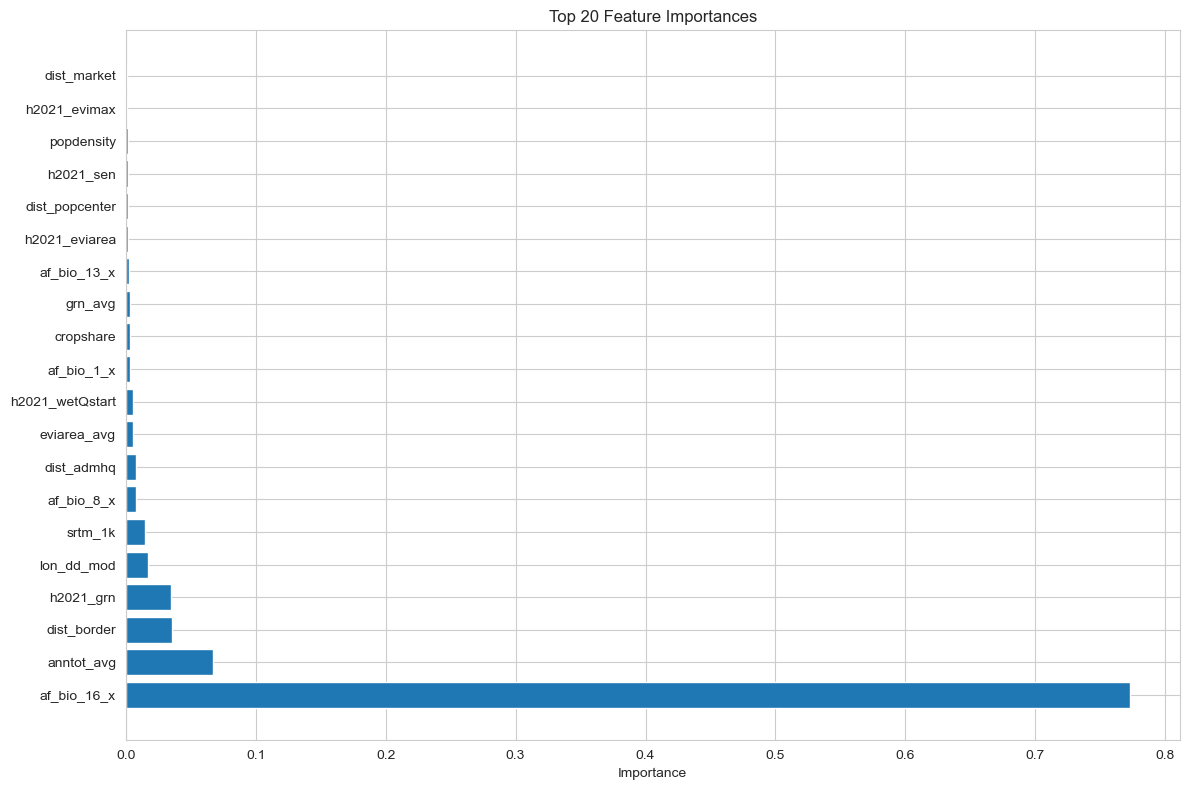

In [21]:
# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 20 Most Important Features:")
    print(feature_importance.head(20).to_string(index=False))
    
    # Visualize
    plt.figure(figsize=(12, 8))
    top_n = 20
    top_features = feature_importance.head(top_n)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance')
    plt.title(f'Top {top_n} Feature Importances')
    plt.tight_layout()
    plt.show()
    
elif hasattr(best_model, 'coef_'):
    # For linear models
    coef_df = pd.DataFrame({
        'feature': X_train.columns,
        'coefficient': best_model.coef_
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print("\nTop 20 Most Important Features (by coefficient magnitude):")
    print(coef_df.head(20).to_string(index=False))
    
    # Visualize
    plt.figure(figsize=(12, 8))
    top_n = 20
    top_features = coef_df.head(top_n)
    plt.barh(range(len(top_features)), top_features['coefficient'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Coefficient')
    plt.title(f'Top {top_n} Feature Coefficients')
    plt.tight_layout()
    plt.show()

## 13. Save Model and Preprocessing Objects

In [23]:
# Save the model, scaler, and feature names
joblib.dump(best_model, 'rainfall_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_names.pkl')

print("Model saved successfully!")
print("  - rainfall_model.pkl")
print("  - scaler.pkl")
print("  - feature_names.pkl")

# Save model performance metrics
metrics = {
    'model_name': best_model_name,
    'best_params': grid_search.best_params_,
    'train_r2': r2_score(y_train, y_pred_train),
    'test_r2': r2_score(y_test, y_pred_test),
    'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
    'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_test)),
    'train_mae': mean_absolute_error(y_train, y_pred_train),
    'test_mae': mean_absolute_error(y_test, y_pred_test)
}

import json
with open('model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print("\nModel metrics saved to model_metrics.json")

Model saved successfully!
  - rainfall_model.pkl
  - scaler.pkl
  - feature_names.pkl

Model metrics saved to model_metrics.json


## 14. Model Usage Example

In [24]:
# Example: How to make predictions with the saved model
print("Example: Making predictions with the saved model\n")

# Load model and scaler
loaded_model = joblib.load('rainfall_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
loaded_features = joblib.load('feature_names.pkl')

# Take a sample from test set
sample = X_test.iloc[0:5]
print("Sample input data:")
print(sample)

# Scale the sample
sample_scaled = loaded_scaler.transform(sample)

# Make prediction
predictions = loaded_model.predict(sample_scaled)

print("\nPredictions:")
for i, pred in enumerate(predictions):
    actual = y_test.iloc[i]
    print(f"  Sample {i+1}: Predicted = {pred:.2f}, Actual = {actual:.2f}, Error = {abs(pred-actual):.2f}")

Example: Making predictions with the saved model

Sample input data:
      dist_road  dist_market  dist_border  dist_popcenter  dist_admhq  \
3921   0.100000     5.300000   456.100006        5.300000         0.0   
1707   0.100000   129.000000   155.399994        0.800000         0.1   
1067  21.200001    36.799999   427.700012       24.900000         0.0   
4850   0.500000     3.100000   161.300003        3.100000         0.0   
1561  27.299999    65.099998   218.399994       65.099998         0.2   

      af_bio_1_x  af_bio_8_x  af_bio_13_x  af_bio_16_x  afmnslp_pct  ...  \
3921         159         156          269          693            8  ...   
1707         250         262           81          185            2  ...   
1067         230         236          155          379            2  ...   
4850         244         261          126          290           11  ...   
1561         249         264          127          278            4  ...   

      ssa_aez09_Tropic-warm/arid  s